# 03 - Exploratory Data Analysis (IT Service Management)

This notebook analyzes cleaned incident data to support IT service decisions in a DSI context.

Main questions addressed:
- Are we meeting SLA commitments?
- Which support groups perform best?
- Which incidents take the longest to resolve?
- Which factors influence resolution delays?
- Where should process improvements be prioritized?

## Executive Summary

This notebook explores the cleaned incident dataset to identify operational patterns affecting IT service performance.

The analysis focuses on:
- SLA compliance
- Resolution performance
- Assignment group efficiency

The findings identify key operational bottlenecks and provide actionable insights for SQL reporting and Power BI dashboard development.

## 1. Project Overview

Goal: explore cleaned incident data to identify service patterns, measure IT support performance, and prepare business recommendations.

Scope: exploratory analysis only. SQL operationalization and dashboard implementation are handled in subsequent notebooks.

## 2. Load Libraries

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

plt.style.use('ggplot')
pd.set_option('display.max_columns', 80)

## 3. Load Clean Dataset

**Business Question:** Is the cleaned dataset reliable for business analysis?

In [2]:
DATA_PATH = Path('../data/processed/incident_clean.csv')

df = pd.read_csv(
    DATA_PATH,
    parse_dates=['opened_at', 'resolved_at', 'closed_at'],
    dtype={'vendor': 'string'},
    low_memory=False,
)

display({'dataset_path': str(DATA_PATH), 'shape': df.shape})

{'dataset_path': '..\\data\\processed\\incident_clean.csv',
 'shape': (24918, 58)}

In [3]:
validation_checks = {
    'shape': df.shape,
    'duplicate_rows': int(df.duplicated().sum()),
    'remaining_missing_values': int(df.isna().sum().sum()),
}

display(validation_checks)

{'shape': (24918, 58), 'duplicate_rows': 0, 'remaining_missing_values': 147404}

## Data Validation

#### Validation Result

The cleaned dataset contains no duplicate records. Missing values remain in optional fields, while core analysis variables are complete and suitable for exploratory analysis.

## 4. Dataset Overview

**Business Question:** What are the main characteristics of the dataset?

In [4]:
overview = {
    'rows': int(df.shape[0]),
    'columns': int(df.shape[1]),
    'memory_mb': float(round(df.memory_usage(deep=True).sum() / 1024**2, 2)),
    'opened_at_min': str(df['opened_at'].min()),
    'opened_at_max': str(df['opened_at'].max()),
}

display(overview)
display(df.dtypes.sort_index())
display(df.head(5))

{'rows': 24918,
 'columns': 58,
 'memory_mb': 43.24,
 'opened_at_min': '2016-02-29 01:16:00',
 'opened_at_max': '2017-02-16 14:17:00'}

active                               bool
assigned_to                           str
assignment_group                      str
caller_id                             str
category                              str
caused_by                             str
closed_at                  datetime64[us]
closed_code                           str
closure_time_hours                float64
cmdb_ci                               str
contact_type                          str
impact                                str
impact_level                        int64
impact_text                           str
incident_day                        int64
incident_day_name                     str
incident_dayofweek                  int64
incident_month                      int64
incident_quarter                    int64
incident_state                        str
incident_week                       int64
incident_year                       int64
is_business_hours                    bool
is_high_impact                    

,number,incident_state,active,reassignment_count,reopen_count,sys_mod_count,made_sla,caller_id,opened_by,opened_at,sys_created_by,sys_created_at,sys_updated_by,sys_updated_at,contact_type,location,category,subcategory,u_symptom,cmdb_ci,impact,urgency,priority,assignment_group,assigned_to,knowledge,u_priority_confirmation,notify,problem_id,rfc,vendor,caused_by,closed_code,resolved_by,resolved_at,closed_at,impact_level,impact_text,urgency_level,urgency_text,priority_level,priority_text,resolution_time_hours,closure_time_hours,incident_year,incident_month,incident_day,incident_dayofweek,incident_quarter,incident_week,incident_day_name,is_business_hours,is_high_priority,is_high_impact,is_high_urgency,sla_compliant,total_modifications,total_rework
0,INC0118026,Closed,False,1,0,10,False,Caller 3328,Opened by 162,2017-02-08 14:58:00,Unassigned,NaN,Updated by 908,2017-02-18 15:00:00,Phone,Location 204,Category 10,Subcategory 158,Symptom 565,NaN,2 - Medium,2 - Medium,3 - Moderate,Group 59,Resolver 137,False,True,Do Not Notify,NaN,NaN,<NA>,NaN,code 6,Resolved by 123,2017-02-13 14:42:00,2017-02-18 15:00:00,2,Medium,2,Medium,3,Moderate,119.73,240.03,2017,2,8,2,1,6,Wednesday,True,False,True,True,0,10,1
1,INC0120304,Closed,False,0,0,2,True,Caller 90,Opened by 8,2017-02-15 02:02:00,Unassigned,NaN,Updated by 21,2017-02-17 00:50:00,Email,Location 188,Category 52,Subcategory 177,Symptom 494,NaN,2 - Medium,2 - Medium,3 - Moderate,Group 64,Resolver 6,False,True,Do Not Notify,NaN,NaN,<NA>,NaN,code 6,Resolved by 5,2017-02-17 00:47:00,2017-02-17 00:50:00,2,Medium,2,Medium,3,Moderate,46.75,46.80,2017,2,15,2,1,7,Wednesday,False,False,True,True,1,2,0
2,INC0121064,Closed,False,1,0,3,True,Caller 116,Opened by 12,2017-02-16 14:17:00,Unassigned,NaN,Updated by 27,2017-02-16 16:38:00,Email,Location 204,Category 42,Subcategory 223,Symptom 494,NaN,2 - Medium,2 - Medium,3 - Moderate,Group 31,Resolver 10,False,True,Do Not Notify,NaN,NaN,<NA>,NaN,code 6,Resolved by 9,2017-02-16 16:38:00,2017-02-16 16:38:00,2,Medium,2,Medium,3,Moderate,2.35,2.35,2017,2,16,3,1,7,Thursday,True,False,True,True,1,3,1
3,INC0120835,Resolved,True,1,0,3,True,Caller 116,Opened by 12,2017-02-16 09:09:00,Unassigned,NaN,Updated by 27,2017-02-16 09:53:00,Email,Location 204,Category 42,Subcategory 223,Symptom 494,NaN,2 - Medium,2 - Medium,3 - Moderate,Group 31,Resolver 10,False,True,Do Not Notify,NaN,NaN,<NA>,NaN,code 9,Resolved by 9,2017-02-16 09:53:00,2017-02-16 09:53:00,2,Medium,2,Medium,3,Moderate,0.73,0.73,2017,2,16,3,1,7,Thursday,True,False,True,True,1,3,1
4,INC0120495,Closed,False,1,0,5,True,Caller 323,Opened by 14,2017-02-15 11:58:00,Unassigned,NaN,Updated by 845,2017-02-16 09:51:00,Phone,Location 135,Category 59,Subcategory 210,Symptom 483,NaN,2 - Medium,2 - Medium,3 - Moderate,Group 24,Resolver 217,False,False,Do Not Notify,NaN,NaN,<NA>,NaN,Unknown,NaN,NaT,2017-02-16 09:51:00,2,Medium,2,Medium,3,Moderate,NaN,21.88,2017,2,15,2,1,7,Wednesday,True,False,True,True,1,5,1


## 5. KPI Overview

**Business Question:** What are the key operational KPIs?

In [5]:
kpi = pd.DataFrame({
    'kpi': [
        'total_incidents',
        'sla_compliance_rate_pct',
        'sla_breach_rate_pct',
        'avg_resolution_time_hours',
        'avg_closure_time_hours',
        'avg_reassignment_count',
        'avg_reopen_count',
    ],
    'value': [
        int(len(df)),
        round(float(df['made_sla'].mean() * 100), 2),
        round(float((1 - df['made_sla'].mean()) * 100), 2),
        round(float(df['resolution_time_hours'].mean(skipna=True)), 2),
        round(float(df['closure_time_hours'].mean(skipna=True)), 2),
        round(float(df['reassignment_count'].mean()), 2),
        round(float(df['reopen_count'].mean()), 2),
    ],
})

display(kpi)

,kpi,value
0,total_incidents,24918.00
1,sla_compliance_rate_pct,63.44
2,sla_breach_rate_pct,36.56
3,avg_resolution_time_hours,178.17
4,avg_closure_time_hours,315.33
5,avg_reassignment_count,0.94
6,avg_reopen_count,0.01


## 6. Incident Volume Analysis

**Business Question:** How is incident workload distributed across time and business dimensions?

,metric,value
0,mean_hours,178.17
1,median_hours,22.10
2,p75_hours,148.48
3,p90_hours,381.55
4,max_hours,8070.17


,number,assignment_group,category,priority_text,resolution_time_hours
0,INC0001839,Group 31,Category 45,Moderate,8070.17
1,INC0001349,Group 67,Category 45,Low,8020.27
2,INC0007343,Group 31,Category 46,Moderate,7803.68
3,INC0001881,Group 35,Category 55,Low,7316.45
4,INC0001978,Group 35,Category 55,Low,7313.93
5,INC0001984,Group 35,Category 55,Low,7313.87
6,INC0019986,Group 3,Category 42,Moderate,7220.58
7,INC0000343,Group 31,Category 45,Low,7122.28
8,INC0000307,Group 66,Category 45,Low,7056.42
9,INC0003982,Group 47,Category 37,Moderate,6729.00


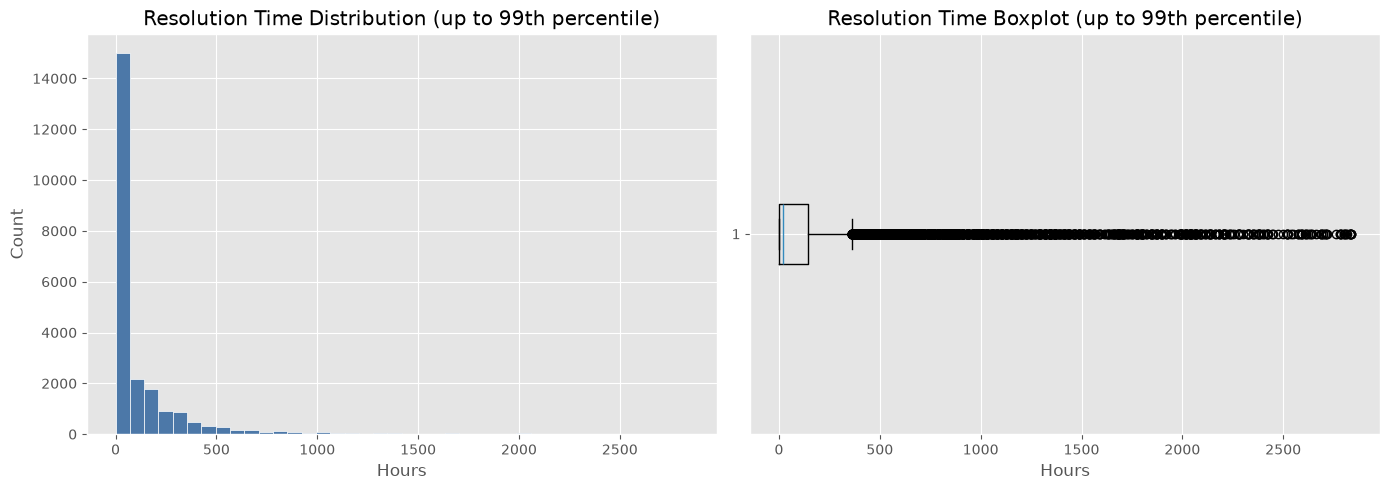

In [13]:
resolution_stats = pd.DataFrame({
    'metric': ['mean_hours', 'median_hours', 'p75_hours', 'p90_hours', 'max_hours'],
    'value': [
        round(float(df['resolution_time_hours'].mean(skipna=True)), 2),
        round(float(df['resolution_time_hours'].median(skipna=True)), 2),
        round(float(df['resolution_time_hours'].quantile(0.75)), 2),
        round(float(df['resolution_time_hours'].quantile(0.90)), 2),
        round(float(df['resolution_time_hours'].max(skipna=True)), 2),
    ],
})

top_10_longest = (
    df[['number', 'assignment_group', 'category', 'priority_text', 'resolution_time_hours']]
    .dropna(subset=['resolution_time_hours'])
    .sort_values('resolution_time_hours', ascending=False)
    .head(10)
    .reset_index(drop=True)
 )

res_clean = df['resolution_time_hours'].dropna()
p99 = res_clean.quantile(0.99)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(res_clean[res_clean <= p99], bins=40, color='#4C78A8', edgecolor='white')
axes[0].set_title('Resolution Time Distribution (up to 99th percentile)')
axes[0].set_xlabel('Hours')
axes[0].set_ylabel('Count')

axes[1].boxplot(res_clean[res_clean <= p99], orientation='horizontal')
axes[1].set_title('Resolution Time Boxplot (up to 99th percentile)')
axes[1].set_xlabel('Hours')

plt.tight_layout()
display(resolution_stats)
display(top_10_longest)

#### Key Insight

Incident volume is concentrated in a limited number of categories and mainly occurs during business days.

#### Business Impact

Preventive actions targeting these categories would reduce workload and improve resource planning.

## 7. SLA Performance Analysis

**Business Question:** Which operational dimensions contribute most to SLA breaches?

,metric,rate_pct
0,SLA compliant,63.44
1,SLA breached,36.56


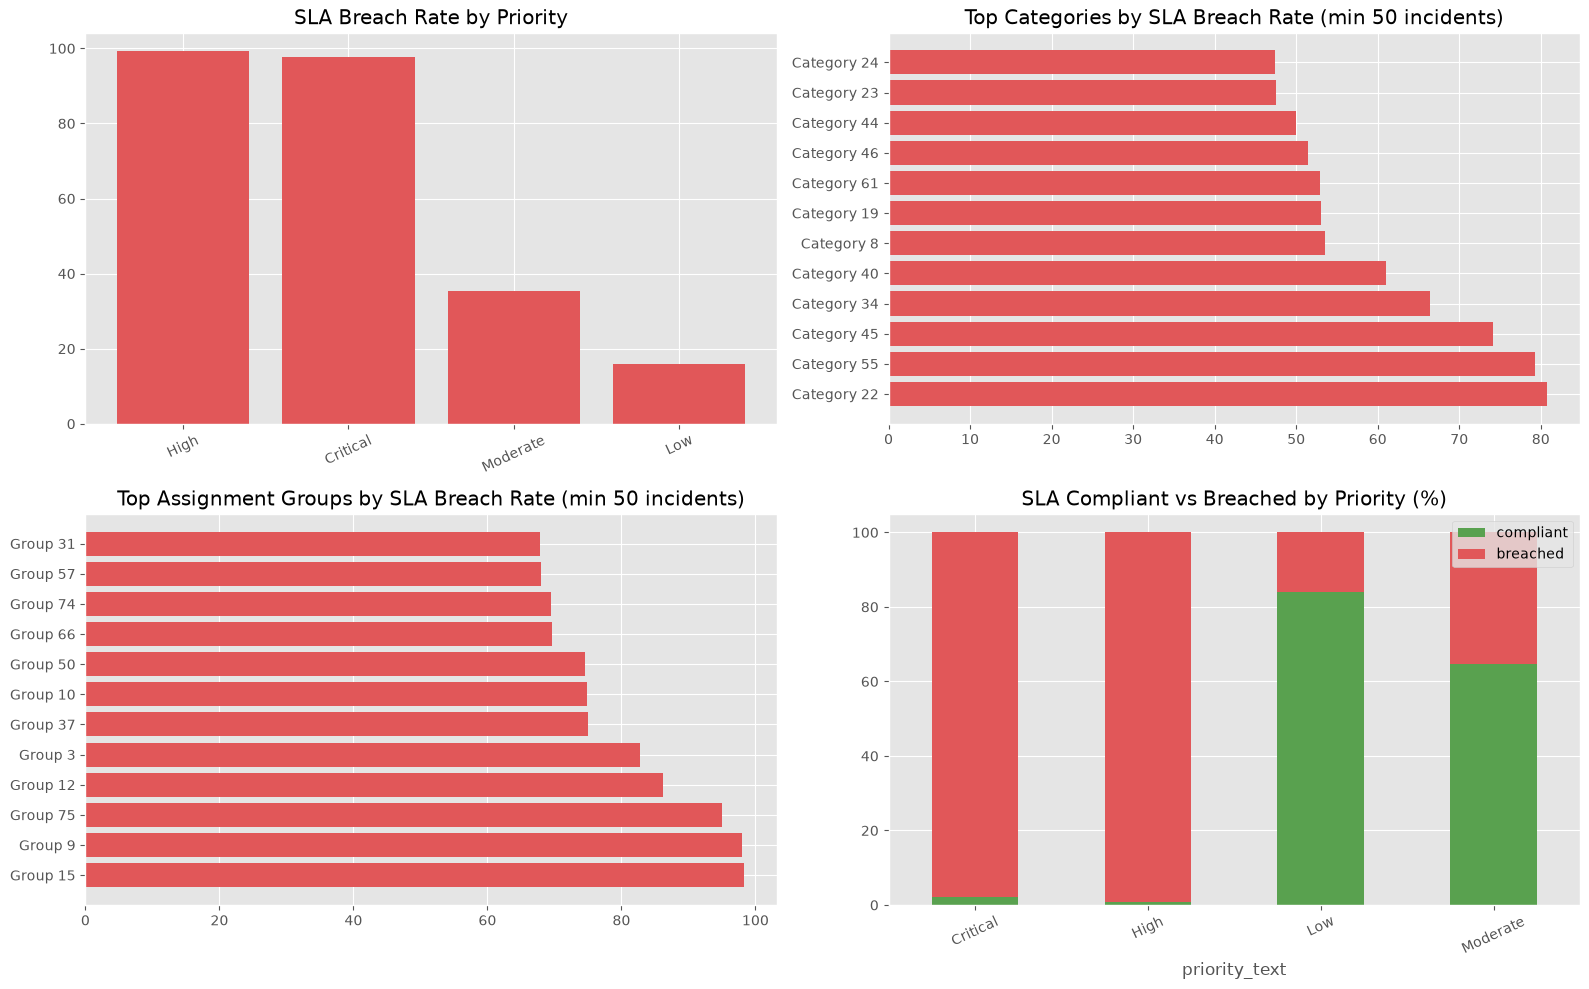

In [7]:
sla_overall = pd.DataFrame({
    'metric': ['SLA compliant', 'SLA breached'],
    'rate_pct': [
        round(float(df['made_sla'].mean() * 100), 2),
        round(float((1 - df['made_sla'].mean()) * 100), 2),
    ],
})

sla_by_priority = (
    df.groupby('priority_text')['made_sla']
    .agg(['count', 'mean'])
    .rename(columns={'count': 'incidents', 'mean': 'sla_rate'})
    .assign(
        sla_rate_pct=lambda x: (x['sla_rate'] * 100).round(2),
        breach_rate_pct=lambda x: ((1 - x['sla_rate']) * 100).round(2),
    )
    .sort_values('breach_rate_pct', ascending=False)
    .reset_index()
 )

sla_by_category = (
    df.groupby('category')['made_sla']
    .agg(['count', 'mean'])
    .rename(columns={'count': 'incidents', 'mean': 'sla_rate'})
    .assign(
        sla_rate_pct=lambda x: (x['sla_rate'] * 100).round(2),
        breach_rate_pct=lambda x: ((1 - x['sla_rate']) * 100).round(2),
    )
    .query('incidents >= 50')
    .sort_values('breach_rate_pct', ascending=False)
    .head(12)
    .reset_index()
 )

sla_by_group = (
    df.groupby('assignment_group')['made_sla']
    .agg(['count', 'mean'])
    .rename(columns={'count': 'incidents', 'mean': 'sla_rate'})
    .assign(
        sla_rate_pct=lambda x: (x['sla_rate'] * 100).round(2),
        breach_rate_pct=lambda x: ((1 - x['sla_rate']) * 100).round(2),
    )
    .query('incidents >= 50')
    .sort_values('breach_rate_pct', ascending=False)
    .head(12)
    .reset_index()
 )

priority_stack = pd.crosstab(df['priority_text'], df['made_sla'], normalize='index') * 100
priority_stack = priority_stack.rename(columns={False: 'breached', True: 'compliant'}).reset_index()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes[0, 0].bar(sla_by_priority['priority_text'], sla_by_priority['breach_rate_pct'], color='#E15759')
axes[0, 0].set_title('SLA Breach Rate by Priority')
axes[0, 0].tick_params(axis='x', rotation=25)

axes[0, 1].barh(sla_by_category['category'], sla_by_category['breach_rate_pct'], color='#E15759')
axes[0, 1].set_title('Top Categories by SLA Breach Rate (min 50 incidents)')

axes[1, 0].barh(sla_by_group['assignment_group'], sla_by_group['breach_rate_pct'], color='#E15759')
axes[1, 0].set_title('Top Assignment Groups by SLA Breach Rate (min 50 incidents)')

priority_stack_plot = priority_stack.set_index('priority_text')[['compliant', 'breached']]
priority_stack_plot.plot(kind='bar', stacked=True, ax=axes[1, 1], color=['#59A14F', '#E15759'])
axes[1, 1].set_title('SLA Compliant vs Breached by Priority (%)')
axes[1, 1].legend(loc='best')
axes[1, 1].tick_params(axis='x', rotation=25)

plt.tight_layout()
display(sla_overall)

#### Key Insight

SLA breaches are concentrated within a small number of priorities, categories, and assignment groups.

#### Business Impact

Improvement efforts should focus on these high-risk areas to maximize SLA compliance.

## 8. Resolution Time Analysis

**Business Question:** Where are the main resolution bottlenecks?

C:\Users\djami\AppData\Local\Temp\ipykernel_31464\3186426169.py:29: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(res_clean[res_clean <= p99], orientation='horizontal')


,metric,value
0,mean_hours,178.17
1,median_hours,22.10
2,p75_hours,148.48
3,p90_hours,381.55
4,max_hours,8070.17


,number,assignment_group,category,priority_text,resolution_time_hours
0,INC0001839,Group 31,Category 45,Moderate,8070.17
1,INC0001349,Group 67,Category 45,Low,8020.27
2,INC0007343,Group 31,Category 46,Moderate,7803.68
3,INC0001881,Group 35,Category 55,Low,7316.45
4,INC0001978,Group 35,Category 55,Low,7313.93
5,INC0001984,Group 35,Category 55,Low,7313.87
6,INC0019986,Group 3,Category 42,Moderate,7220.58
7,INC0000343,Group 31,Category 45,Low,7122.28
8,INC0000307,Group 66,Category 45,Low,7056.42
9,INC0003982,Group 47,Category 37,Moderate,6729.00


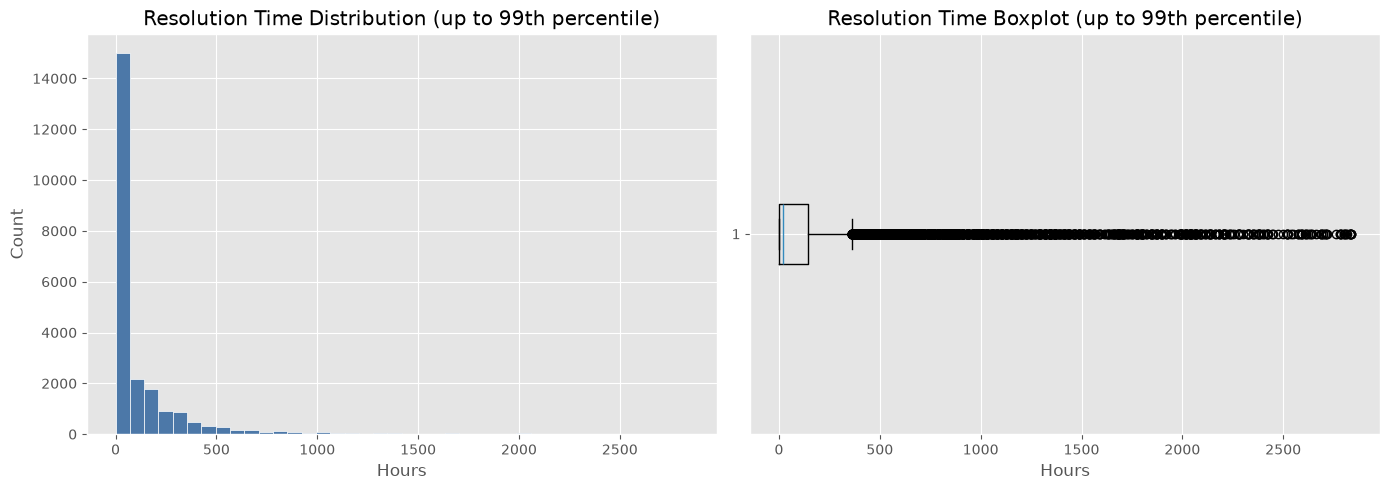

In [8]:
resolution_stats = pd.DataFrame({
    'metric': ['mean_hours', 'median_hours', 'p75_hours', 'p90_hours', 'max_hours'],
    'value': [
        round(float(df['resolution_time_hours'].mean(skipna=True)), 2),
        round(float(df['resolution_time_hours'].median(skipna=True)), 2),
        round(float(df['resolution_time_hours'].quantile(0.75)), 2),
        round(float(df['resolution_time_hours'].quantile(0.90)), 2),
        round(float(df['resolution_time_hours'].max(skipna=True)), 2),
    ],
})

top_10_longest = (
    df[['number', 'assignment_group', 'category', 'priority_text', 'resolution_time_hours']]
    .dropna(subset=['resolution_time_hours'])
    .sort_values('resolution_time_hours', ascending=False)
    .head(10)
    .reset_index(drop=True)
 )

res_clean = df['resolution_time_hours'].dropna()
p99 = res_clean.quantile(0.99)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(res_clean[res_clean <= p99], bins=40, color='#4C78A8', edgecolor='white')
axes[0].set_title('Resolution Time Distribution (up to 99th percentile)')
axes[0].set_xlabel('Hours')
axes[0].set_ylabel('Count')

axes[1].boxplot(res_clean[res_clean <= p99], orientation='horizontal')
axes[1].set_title('Resolution Time Boxplot (up to 99th percentile)')
axes[1].set_xlabel('Hours')

plt.tight_layout()
display(resolution_stats)
display(top_10_longest)

#### Key Insight

Most incidents are resolved quickly, while a few outliers drive the average resolution time upward.

#### Business Impact

Monitoring long-running incidents separately would provide more meaningful performance indicators.

## 9. Priority & Impact Analysis

**Business Question:** How do incident characteristics affect resolution time?

,priority_text,incidents,avg_hours,median_hours
0,Critical,270,266.08,80.24
1,High,408,152.46,38.23
2,Low,674,283.19,5.02
3,Moderate,22010,174.35,21.55


,impact_text,incidents,avg_hours,median_hours
0,High,421,216.30,54.22
1,Low,651,262.97,4.18
2,Medium,22290,174.97,21.88


,urgency_text,incidents,avg_hours,median_hours
0,High,531,218.54,69.12
1,Low,607,273.14,3.70
2,Medium,22224,174.61,21.72


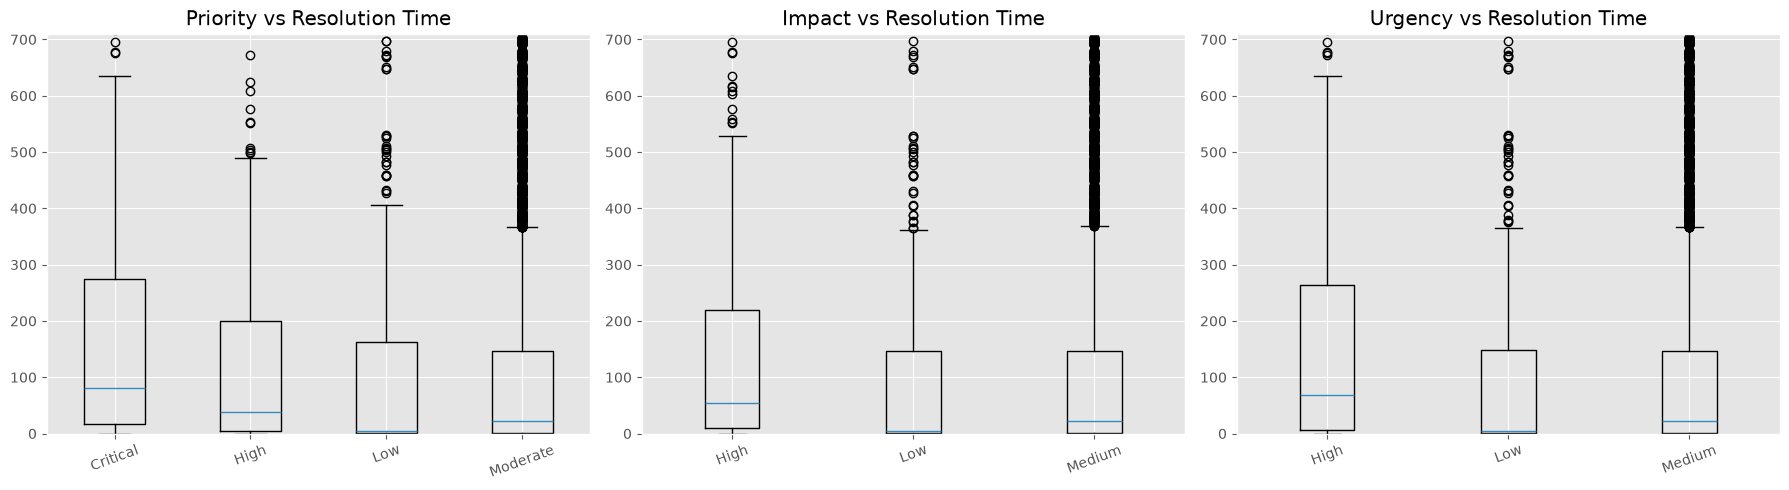

In [9]:
priority_vs_time = (
    df.groupby('priority_text')['resolution_time_hours']
    .agg(['count', 'mean', 'median'])
    .rename(columns={'count': 'incidents', 'mean': 'avg_hours', 'median': 'median_hours'})
    .round(2)
    .reset_index()
 )

impact_vs_time = (
    df.groupby('impact_text')['resolution_time_hours']
    .agg(['count', 'mean', 'median'])
    .rename(columns={'count': 'incidents', 'mean': 'avg_hours', 'median': 'median_hours'})
    .round(2)
    .reset_index()
 )

urgency_vs_time = (
    df.groupby('urgency_text')['resolution_time_hours']
    .agg(['count', 'mean', 'median'])
    .rename(columns={'count': 'incidents', 'mean': 'avg_hours', 'median': 'median_hours'})
    .round(2)
    .reset_index()
 )

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
box_data_priority = [df.loc[df['priority_text'] == lvl, 'resolution_time_hours'].dropna() for lvl in priority_vs_time['priority_text']]
axes[0].boxplot(box_data_priority, tick_labels=priority_vs_time['priority_text'].tolist())
axes[0].set_ylim(0, df['resolution_time_hours'].quantile(0.95))
axes[0].set_title('Priority vs Resolution Time')
axes[0].tick_params(axis='x', rotation=20)

box_data_impact = [df.loc[df['impact_text'] == lvl, 'resolution_time_hours'].dropna() for lvl in impact_vs_time['impact_text']]
axes[1].boxplot(box_data_impact, tick_labels=impact_vs_time['impact_text'].tolist())
axes[1].set_ylim(0, df['resolution_time_hours'].quantile(0.95))
axes[1].set_title('Impact vs Resolution Time')
axes[1].tick_params(axis='x', rotation=20)

box_data_urgency = [df.loc[df['urgency_text'] == lvl, 'resolution_time_hours'].dropna() for lvl in urgency_vs_time['urgency_text']]
axes[2].boxplot(box_data_urgency, tick_labels=urgency_vs_time['urgency_text'].tolist())
axes[2].set_ylim(0, df['resolution_time_hours'].quantile(0.95))
axes[2].set_title('Urgency vs Resolution Time')
axes[2].tick_params(axis='x', rotation=20)

plt.tight_layout()
display(priority_vs_time)
display(impact_vs_time)
display(urgency_vs_time)

#### Key Insight

Priority influences resolution time, but operational factors also contribute to delays.

#### Business Impact

Workflow optimization should complement priority-based management.

## 10. Assignment Group Performance

**Business Question:** Which assignment groups perform most efficiently?

,assignment_group,incidents,sla_rate,avg_resolution_hours,avg_reopen,avg_reassignment,sla_rate_pct,breach_rate_pct
0,Group 15,58,0.017241,2081.09,0.00,1.71,1.72,98.28
1,Group 9,96,0.020833,3648.39,0.02,1.97,2.08,97.92
2,Group 75,60,0.050000,676.74,0.05,0.70,5.00,95.00
3,Group 12,123,0.138211,335.77,0.00,1.03,13.82,86.18
4,Group 3,99,0.171717,1309.91,0.00,1.14,17.17,82.83
5,Group 37,176,0.250000,412.19,0.01,0.86,25.00,75.00
6,Group 10,343,0.250729,597.16,0.02,1.01,25.07,74.93
7,Group 50,51,0.254902,380.80,0.00,1.57,25.49,74.51
8,Group 66,376,0.303191,498.59,0.01,0.82,30.32,69.68
9,Group 74,105,0.304762,249.77,0.04,1.29,30.48,69.52


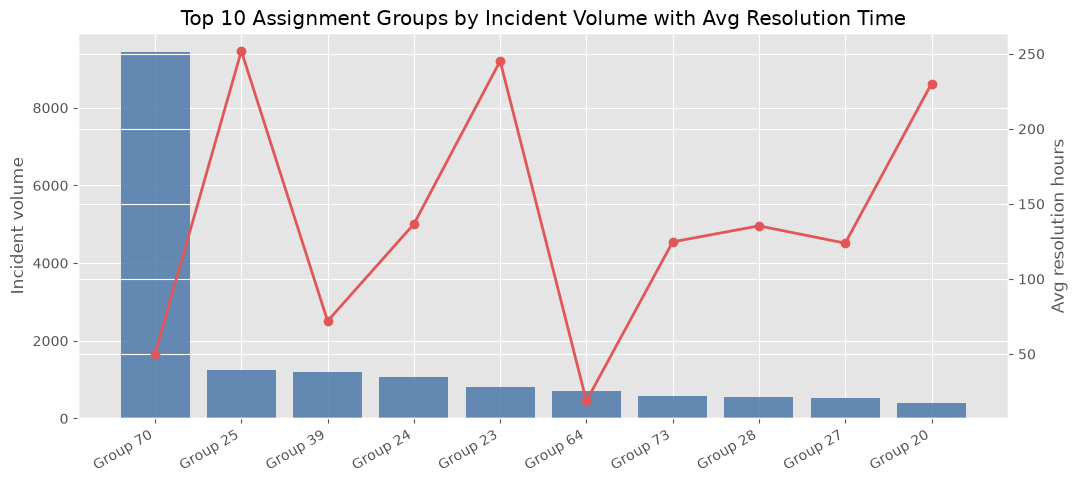

In [10]:
group_perf = (
    df.groupby('assignment_group')
    .agg(
        incidents=('number', 'count'),
        sla_rate=('made_sla', 'mean'),
        avg_resolution_hours=('resolution_time_hours', 'mean'),
        avg_reopen=('reopen_count', 'mean'),
        avg_reassignment=('reassignment_count', 'mean'),
    )
    .assign(
        sla_rate_pct=lambda x: (x['sla_rate'] * 100).round(2),
        breach_rate_pct=lambda x: ((1 - x['sla_rate']) * 100).round(2),
        avg_resolution_hours=lambda x: x['avg_resolution_hours'].round(2),
        avg_reopen=lambda x: x['avg_reopen'].round(2),
        avg_reassignment=lambda x: x['avg_reassignment'].round(2),
    )
    .query('incidents >= 50')
    .sort_values(['breach_rate_pct', 'avg_resolution_hours'], ascending=[False, False])
    .reset_index()
 )

top_groups_volume = group_perf.sort_values('incidents', ascending=False).head(10)

fig, ax1 = plt.subplots(figsize=(12, 5))
x_pos = np.arange(len(top_groups_volume))
bars = ax1.bar(x_pos, top_groups_volume['incidents'], color='#4C78A8', alpha=0.85, label='Incident volume')
ax1.set_ylabel('Incident volume')
ax1.set_title('Top 10 Assignment Groups by Incident Volume with Avg Resolution Time')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(top_groups_volume['assignment_group'], rotation=30, ha='right')

ax2 = ax1.twinx()
ax2.plot(x_pos, top_groups_volume['avg_resolution_hours'], color='#E15759', marker='o', linewidth=2, label='Avg resolution hours')
ax2.set_ylabel('Avg resolution hours')

display(group_perf.head(15))

#### Key Insight

Assignment groups show significant differences in SLA compliance and resolution time.

#### Business Impact

Best-performing teams can serve as operational benchmarks.

## 11. Reassignment & Reopen Analysis

**Business Question:** What is the operational impact of reassignments and reopens?

,reassignment_bucket,incidents,avg_hours,median_hours
0,0,12003,94.98,0.68
1,1,6228,173.32,42.05
2,2-3,3517,335.62,122.93
3,4+,1614,472.47,239.31


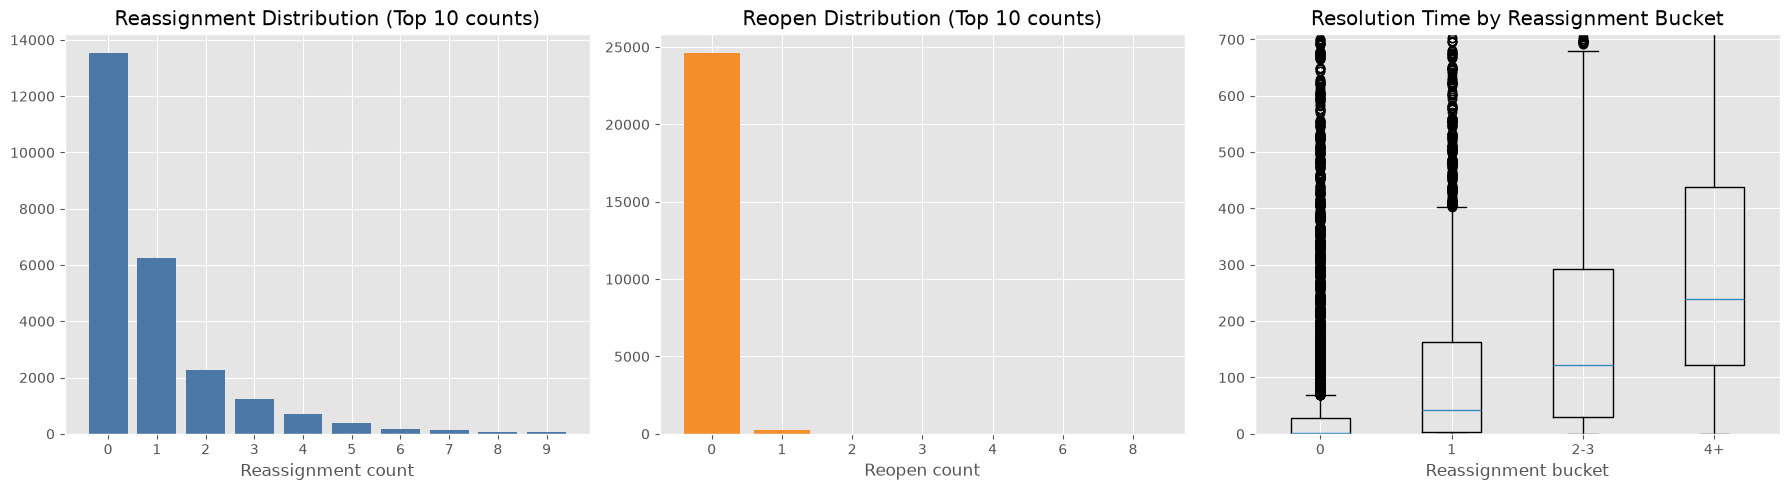

In [11]:
reassign_dist = df['reassignment_count'].value_counts().sort_index().reset_index()
reassign_dist.columns = ['reassignment_count', 'incidents']

reopen_dist = df['reopen_count'].value_counts().sort_index().reset_index()
reopen_dist.columns = ['reopen_count', 'incidents']

df['reassignment_bucket'] = pd.cut(
    df['reassignment_count'],
    bins=[-1, 0, 1, 3, 100],
    labels=['0', '1', '2-3', '4+'],
)

time_by_reassign_bucket = (
    df.groupby('reassignment_bucket', observed=False)['resolution_time_hours']
    .agg(['count', 'mean', 'median'])
    .rename(columns={'count': 'incidents', 'mean': 'avg_hours', 'median': 'median_hours'})
    .round(2)
    .reset_index()
 )

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].bar(reassign_dist.head(10)['reassignment_count'].astype(str), reassign_dist.head(10)['incidents'], color='#4C78A8')
axes[0].set_title('Reassignment Distribution (Top 10 counts)')
axes[0].set_xlabel('Reassignment count')

axes[1].bar(reopen_dist.head(10)['reopen_count'].astype(str), reopen_dist.head(10)['incidents'], color='#F28E2B')
axes[1].set_title('Reopen Distribution (Top 10 counts)')
axes[1].set_xlabel('Reopen count')

bucket_order = time_by_reassign_bucket['reassignment_bucket'].astype(str).tolist()
bucket_data = [
    df.loc[df['reassignment_bucket'].astype(str) == b, 'resolution_time_hours'].dropna()
    for b in bucket_order
]
axes[2].boxplot(bucket_data, tick_labels=bucket_order)
axes[2].set_ylim(0, df['resolution_time_hours'].quantile(0.95))
axes[2].set_title('Resolution Time by Reassignment Bucket')
axes[2].set_xlabel('Reassignment bucket')

plt.tight_layout()
display(time_by_reassign_bucket)

#### Key Insight

Incidents with multiple reassignments require substantially longer resolution times.

#### Business Impact

Improving first-line routing would reduce delays and operational rework.

## 12. Temporal Analysis

**Business Question:** How does incident timing influence operational performance?

NameError: name 'incidents_by_month' is not defined

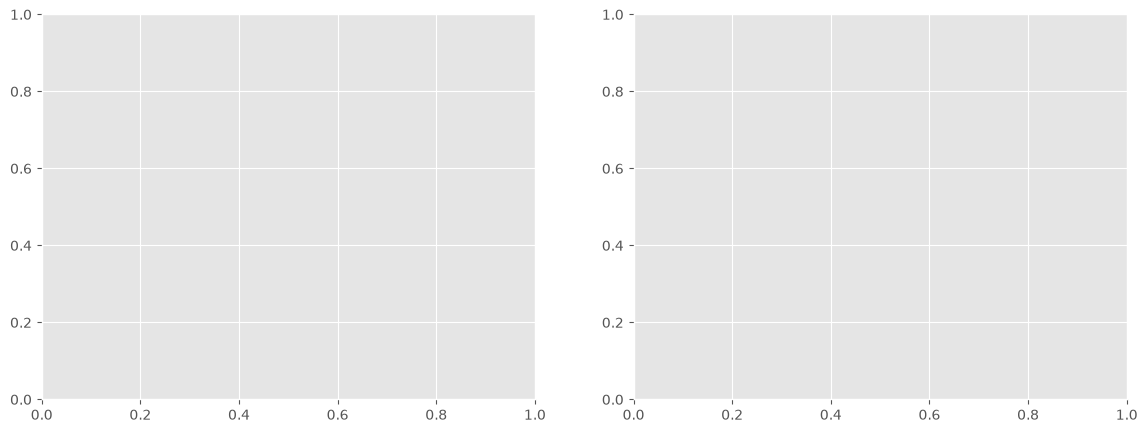

In [12]:
incidents_by_hour = df['opened_at'].dt.hour.value_counts().sort_index().reset_index()
incidents_by_hour.columns = ['hour', 'incident_count']

business_hours_perf = (
    df.groupby('is_business_hours')['resolution_time_hours']
    .agg(['count', 'mean', 'median'])
    .rename(columns={'count': 'incidents', 'mean': 'avg_hours', 'median': 'median_hours'})
    .round(2)
    .reset_index()
 )

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(incidents_by_month['opened_at'], incidents_by_month['incident_count'], color='#4C78A8', marker='o', linewidth=1.5)
axes[0].set_title('Incident Volume by Month')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(incidents_by_hour['hour'], incidents_by_hour['incident_count'], color='#59A14F')
axes[1].set_title('Incident Volume by Hour')
axes[1].set_xlabel('Hour of day')

plt.tight_layout()
display(business_hours_perf)

#### Key Insight

Incident volume follows predictable business activity patterns.

#### Business Impact

Aligning staffing with demand peaks would improve service responsiveness.

## 13. Correlation Analysis

**Business Question:** Which operational metrics are most strongly associated with resolution delays?

resolution_time_hours    1.000000
closure_time_hours       0.964905
sys_mod_count            0.899511
total_modifications      0.899511
total_rework             0.209820
reassignment_count       0.208123
reopen_count             0.053793
impact_level             0.014699
urgency_level            0.013182
priority_level           0.008933
Name: resolution_time_hours, dtype: float64

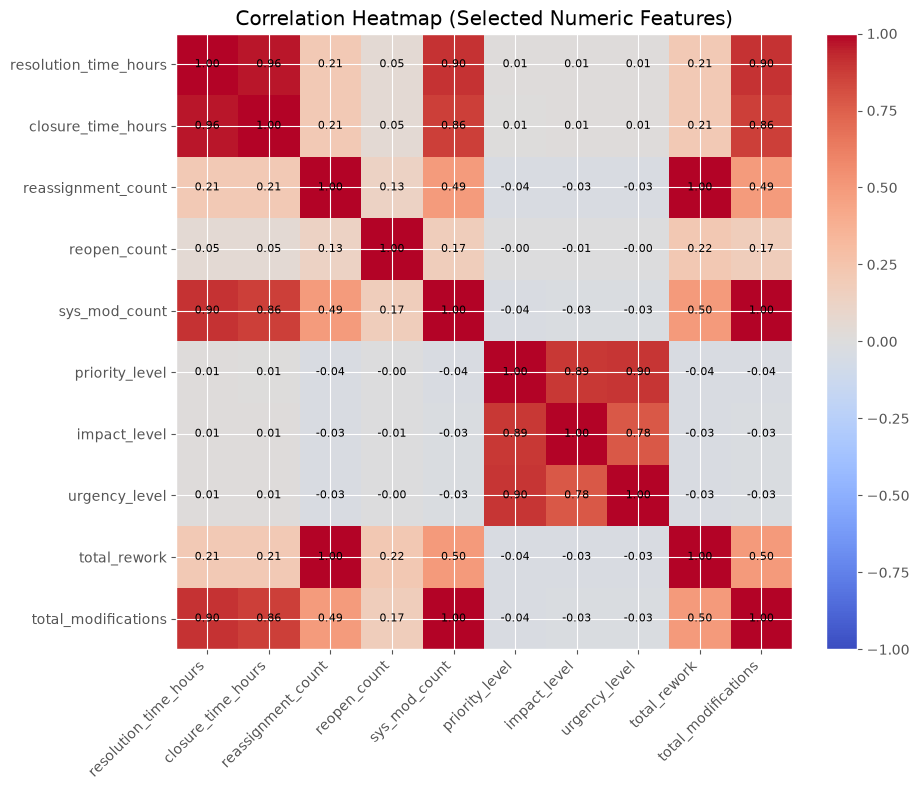

In [ ]:
corr_cols = [
    'resolution_time_hours',
    'closure_time_hours',
    'reassignment_count',
    'reopen_count',
    'sys_mod_count',
    'priority_level',
    'impact_level',
    'urgency_level',
    'total_rework',
    'total_modifications',
]

corr_df = df[corr_cols].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr_df.values, cmap='coolwarm', vmin=-1, vmax=1)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_xticks(np.arange(len(corr_cols)))
ax.set_yticks(np.arange(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=45, ha='right')
ax.set_yticklabels(corr_cols)
ax.set_title('Correlation Heatmap (Selected Numeric Features)')

for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        ax.text(j, i, f"{corr_df.values[i, j]:.2f}", ha='center', va='center', color='black', fontsize=8)

plt.tight_layout()
display(corr_df['resolution_time_hours'].sort_values(ascending=False))

#### Key Insight

Rework-related variables show the strongest association with resolution time.

#### Business Impact

Reducing rework is likely to improve overall service performance.

## 14. Business Insights

Data-backed observations for IT service management decisions (max 10).

In [ ]:
insight_rows = []

overall_sla = float(df['made_sla'].mean() * 100)
insight_rows.append({
    'Insight': 'Overall SLA baseline',
    'Evidence': f"SLA compliance = {overall_sla:.1f}% and breaches = {100 - overall_sla:.1f}%.",
})

if not sla_by_priority.empty:
    worst_priority = sla_by_priority.iloc[0]
    insight_rows.append({
        'Insight': 'Highest breach priority',
        'Evidence': f"Priority '{worst_priority['priority_text']}' breach rate = {worst_priority['breach_rate_pct']:.1f}% over {int(worst_priority['incidents'])} incidents.",
    })

long_reassign = time_by_reassign_bucket[time_by_reassign_bucket['reassignment_bucket'] == '4+']
no_reassign = time_by_reassign_bucket[time_by_reassign_bucket['reassignment_bucket'] == '0']
if not long_reassign.empty and not no_reassign.empty:
    ratio = long_reassign['avg_hours'].iloc[0] / max(no_reassign['avg_hours'].iloc[0], 0.001)
    insight_rows.append({
        'Insight': 'Reassignment impact on delays',
        'Evidence': f"Incidents with 4+ reassignments take about {ratio:.1f}x longer than incidents with no reassignment.",
    })

if not business_hours_perf.empty:
    in_hours = business_hours_perf[business_hours_perf['is_business_hours'] == True]['avg_hours']
    out_hours = business_hours_perf[business_hours_perf['is_business_hours'] == False]['avg_hours']
    if not in_hours.empty and not out_hours.empty:
        insight_rows.append({
            'Insight': 'Business hours effect',
            'Evidence': f"Outside business hours avg resolution = {out_hours.iloc[0]:.1f}h vs {in_hours.iloc[0]:.1f}h in business hours.",
        })

if not group_perf.empty:
    top_breach_group = group_perf.iloc[0]
    insight_rows.append({
        'Insight': 'Most exposed assignment group',
        'Evidence': f"Group '{top_breach_group['assignment_group']}' breach rate = {top_breach_group['breach_rate_pct']:.1f}% across {int(top_breach_group['incidents'])} incidents.",
    })

if not sla_by_category.empty:
    top_category_breach = sla_by_category.iloc[0]
    insight_rows.append({
        'Insight': 'Category with highest breaches',
        'Evidence': f"Category '{top_category_breach['category']}' breach rate = {top_category_breach['breach_rate_pct']:.1f}% for {int(top_category_breach['incidents'])} incidents.",
    })

corr_rework = corr_df.loc['resolution_time_hours', 'total_rework']
insight_rows.append({
    'Insight': 'Rework correlation',
    'Evidence': f"Resolution time correlation with total rework = {corr_rework:.2f}.",
})

if not top_10_longest.empty:
    top_long = top_10_longest['resolution_time_hours'].iloc[0]
    insight_rows.append({
        'Insight': 'Extreme delay cases',
        'Evidence': f"Longest incident resolution time = {top_long:.1f} hours.",
    })

insights_df = pd.DataFrame(insight_rows[:10])
display(insights_df)

,Insight,Evidence
0,Overall SLA baseline,SLA compliance = 63.4% and breaches = 36.6%.
1,Highest breach priority,Priority 'High' breach rate = 99.3% over 408 i...
2,Reassignment impact on delays,Incidents with 4+ reassignments take about 5.0...
3,Business hours effect,Outside business hours avg resolution = 106.7h...
4,Most exposed assignment group,Group 'Group 15' breach rate = 98.3% across 58...
5,Category with highest breaches,Category 'Category 22' breach rate = 80.8% for...
6,Rework correlation,Resolution time correlation with total rework ...
7,Extreme delay cases,Longest incident resolution time = 8070.2 hours.


## 15. Recommendations

Operational recommendations based on observed patterns.

In [ ]:
recommendations = pd.DataFrame({
    'recommendation': [
        'Reduce reassignment loops with stronger first-line triage rules.',
        'Prioritize coaching and capacity planning for high-breach assignment groups.',
        'Review category-level workflows where breach rates are highest.',
        'Strengthen off-hours coverage or escalation for incidents opened outside business hours.',
        'Improve knowledge-base usage for repeat/reopen-heavy incident types.',
        'Refine priority calibration to align urgency/impact with actual resolution risk.',
    ],
    'expected_impact': [
        'Lower resolution delays and reduced total rework.',
        'Improved SLA compliance and faster resolution in critical teams.',
        'Reduced process bottlenecks in problematic service domains.',
        'Better consistency of resolution times across time windows.',
        'Fewer reopens and fewer repetitive handling actions.',
        'More reliable prioritization and better operational focus.',
    ],
})

display(recommendations)

,recommendation,expected_impact
0,Reduce reassignment loops with stronger first-...,Lower resolution delays and reduced total rework.
1,Prioritize coaching and capacity planning for ...,Improved SLA compliance and faster resolution ...
2,Review category-level workflows where breach r...,Reduced process bottlenecks in problematic ser...
3,Strengthen off-hours coverage or escalation fo...,Better consistency of resolution times across ...
4,Improve knowledge-base usage for repeat/reopen...,Fewer reopens and fewer repetitive handling ac...
5,Refine priority calibration to align urgency/i...,More reliable prioritization and better operat...


## 16. Conclusion

This exploratory analysis identified the key operational drivers affecting IT service performance, including SLA compliance, resolution delays, reassignment behavior, and assignment group efficiency.

The insights generated in this notebook establish the analytical foundation for SQL KPI modeling and the interactive Power BI dashboard presented in the following stages of the project.